# 決定木による信用リスクスコアカード（PROC HPSPLIT）

## エグゼクティブサマリー

本ノートブックは、PROC HPSPLITを用いて個人向け融資ポートフォリオの解釈可能な債務不履行スコアカードを構築する。合成された申込者データにエントロピー基準で分類木を成長させ、コストコンプレキシティで枝刈りし、適合統計量、変数重要度、ROC/AUC、そしてスコアリング木そのものを読み取る——これは銀行のリスクチームが文書化する、透明で規制当局にも説明しやすいモデルそのものである。すべての申込者はリーフにスコア付けでき、木全体はデプロイ可能なDATAステップコードとしてエクスポートできる。

## データソース

| データセット | 行数 | 説明 | 主な変数 |
|---------|------|-------------|---------------|
| `applicants` | 100 | `rand()` によりインラインで生成された合成の個人向け融資申込者データ。二値の `default` フラグはロジスティックリスクスコアから抽出され、DTI・与信枠使用率・最近の延滞・短い信用履歴が悪いほど債務不履行確率が高まるようになっている。 | `default`（イベント=`'1'`）、`dti`、`utilization`、`fico`、`credit_age`、`n_delinq`、`loan_amount`、`income`、`home`（own/rent/mortgage）、`purpose`（debt/home/auto/other） |

DATAステップはより大きなループを要求するが、この環境は無償版モードで動作し最初の100観測のみを実体化する——それでも解釈可能なスコアカード木を成長させ読み取るには十分な、コンパクトかつ完全に再現可能な申込者台帳である。

# 決定木による信用リスクスコアカード

銀行には**正確で説明可能な**債務不履行モデルが必要である——与信担当者（そして規制当局）は、なぜある申込者が高リスクとスコア付けされたのかを正確に追跡できなければならない。枝刈りされた決定木はまさにそれを提供する：すべての予測は人間が読める短い分岐の連鎖である。

本ノートブックでは：

1. 個人向け融資申込台帳を合成する。
2. `PROC HPSPLIT` を用いてエントロピー基準で分類木を成長させる。
3. コストコンプレキシティで枝刈りし、過学習を防ぐ。
4. 適合統計量、変数重要度、ROC/AUC、そして木そのものを確認する。
5. 新しい申込に対して展開できるDATAステップのスコアリングコードを出力する。

## 1. 合成融資台帳の生成

古典的なスコアカードの要因——負債収入比率、リボルビング与信枠使用率、FICOスコア、信用履歴の長さ、直近の延滞——のロジスティック関数として債務不履行確率を持つ申込者を生成する。その確率を用いたベルヌーイ分布から観測される `default` フラグを抽出するため、シグナルは本物でありながらノイズを含む——実運用データそのものである。ここでは最初の100件の申込者を実体化する。

                                                   The FREQ Procedure

デフォルト（債務不履行）                            Frequency    Percent
-------------------------------------------------------------
0                                              79     79.00
1                                              21     21.00

居住形態               Frequency    Percent
----------------------------------------
住宅ローン                     34     34.00
持ち家                       31     31.00
賃貸                        35     35.00

借入目的            Frequency    Percent
-------------------------------------
その他                    12     12.00
住宅資金                   28     28.00
債務整理                   37     37.00
自動車                    23     23.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


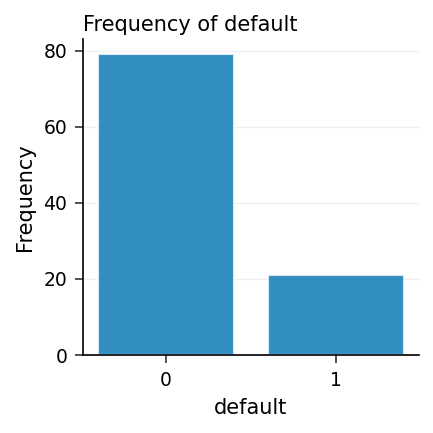

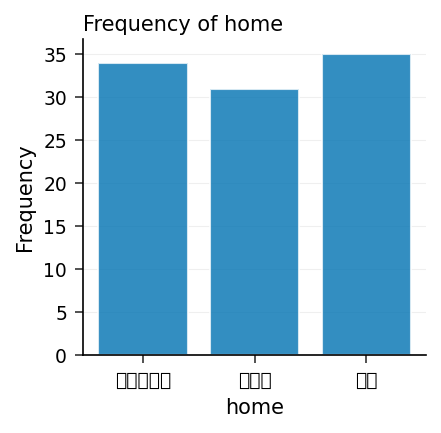

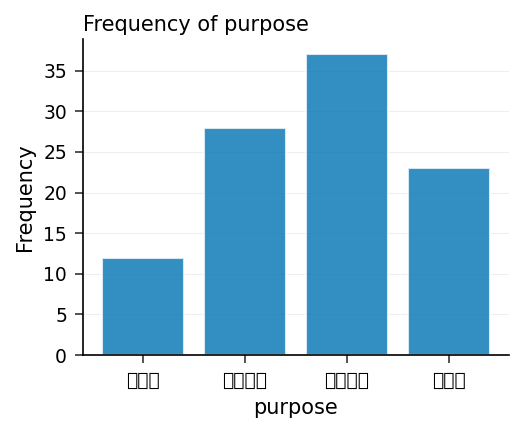

In [1]:
データ applicants;
   呼出 streaminit(20260531);
   長さ home $16 purpose $16;
   繰返 id = 1 から 100;
      /* 借主の財務プロフィール */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* カテゴリ属性 */
      u = rand('uniform');
      もし u < 0.34 なら home = '賃貸';
      他 もし u < 0.70 なら home = '住宅ローン';
      他 home = '持ち家';

      v = rand('uniform');
      もし v < 0.40 なら purpose = '債務整理';
      他 もし v < 0.65 なら purpose = '住宅資金';
      他 もし v < 0.85 なら purpose = '自動車';
      他 purpose = 'その他';

      /* 潜在的な債務不履行リスク：DTI・与信枠使用率・延滞が悪化し、
         FICOが低く信用履歴が短いほどログオッズが上昇する。 */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = '賃貸')
            + 0.25 * (purpose = '債務整理');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      削除 u v eta p;
      出力;
   終了;
実行;

処理 度数 データ=applicants;
   TABLES default home purpose / nocum;
   見出 default = 'デフォルト（債務不履行）'
         home    = '居住形態'
         purpose = '借入目的';
実行;

`PROC FREQ` の出力は、不均衡だが扱いやすい債務不履行率——申込者およそ5人に1人が債務不履行（100件中21件）——と、居住形態・借入目的カテゴリにわたる妥当な分布を確認させる：消費者向け融資ポートフォリオで想定される周辺分布そのものである。付随する棒グラフはそれぞれの周辺分布を可視化する。

## 2. スコアカード木の成長と枝刈り

`default` を二値分類ターゲットとしてモデル化し、`event='1'` と指定することで、感度/特異度/AUCの統計量がすべて*債務不履行*クラスに向けられるようにする。以下を行う：

- カテゴリ予測変数と応答変数を `CLASS` で宣言する、
- **エントロピー**（情報利得）基準で木を成長させる、
- 木がノイズを記憶しないよう**コストコンプレキシティ**で枝刈りする、
- **木全体の図**と**ROC曲線**を要求する。


                                                 The HPSPLIT Procedure                                                  

  Response variable: デフォルト（債務不履行）
  Class variable: デフォルト（債務不履行）
  Class variable: 居住形態
  Class variable: 借入目的
  Predictor variable: 負債収入比率
  Predictor variable: 与信枠使用率
  Predictor variable: FICOスコア
  Predictor variable: 信用履歴年数
  Predictor variable: 延滞回数
  Predictor variable: 融資額
  Predictor variable: 年収
  Predictor variable: 居住形態
  Predictor variable: 借入目的

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.04000


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


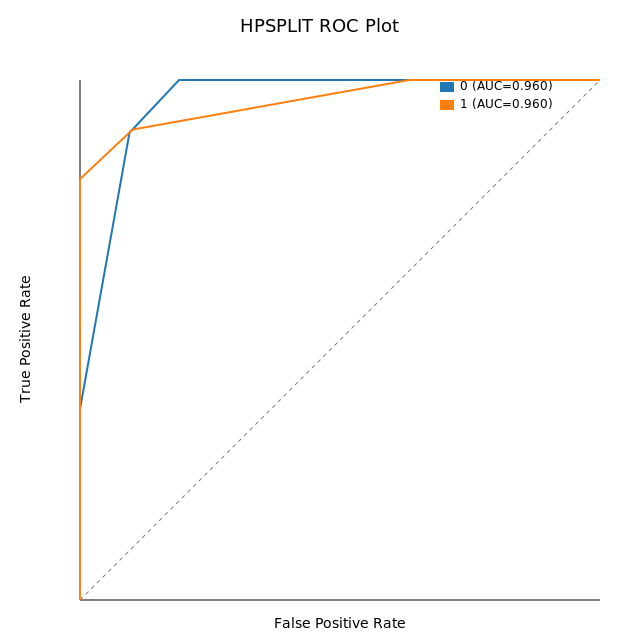

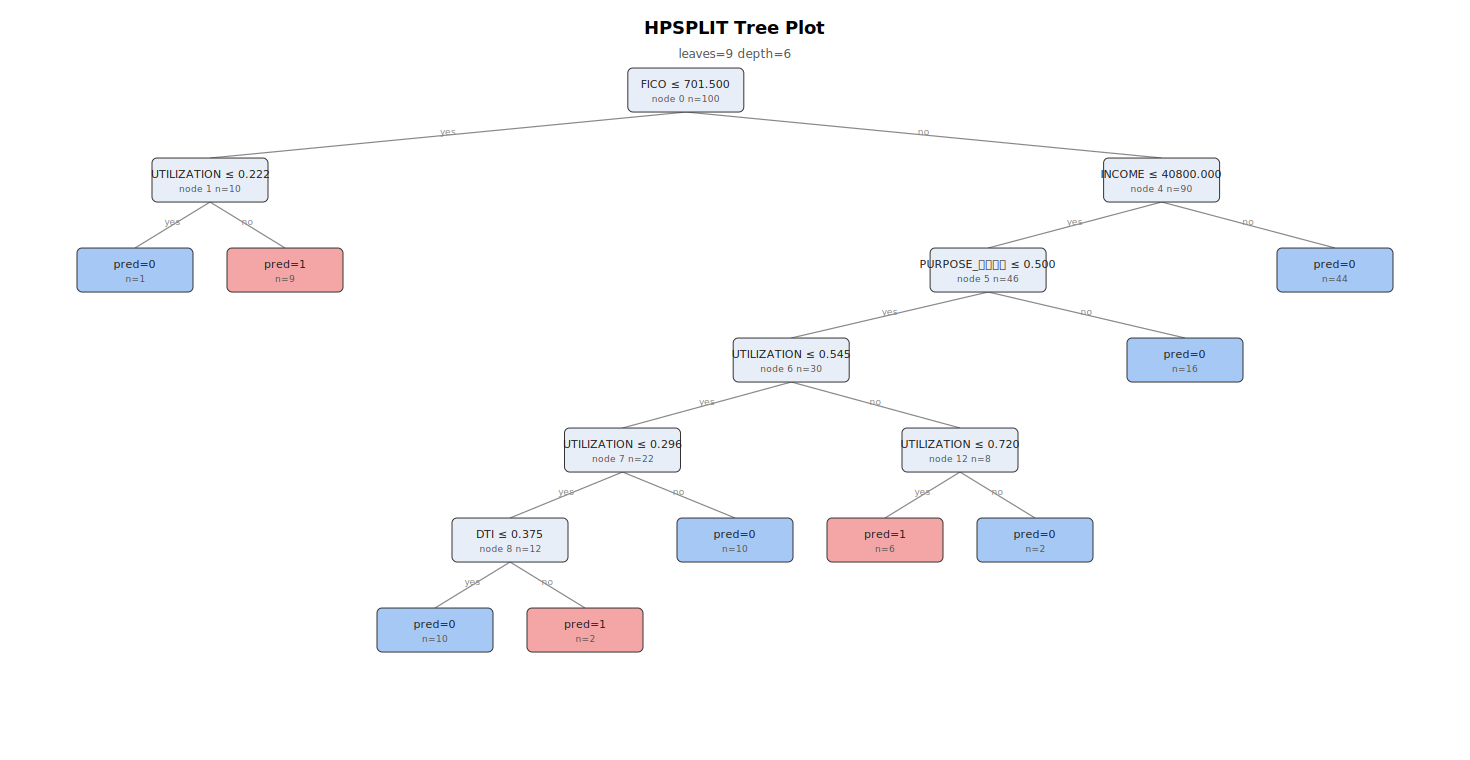

In [2]:
ODS GRAPHICS ON;

処理 hpsplit データ=applicants seed=20260531
             PLOTS=(wholetree roc);
   分類 default home purpose;
   模型 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   見出 default     = 'デフォルト（債務不履行）'
         dti          = '負債収入比率'
         utilization  = '与信枠使用率'
         fico         = 'FICOスコア'
         credit_age   = '信用履歴年数'
         n_delinq     = '延滞回数'
         loan_amount  = '融資額'
         income       = '年収'
         home         = '居住形態'
         purpose      = '借入目的';
実行;

**適合統計量**（正解率、誤分類率、対数損失）と**クラス別ROC/AUC**は、枝刈りされた木が債務不履行者と非債務不履行者をどれだけ明瞭に切り分けているかを示す。**変数重要度**表は、どの属性が分岐を駆動しているかを順位付けする——ここでは**与信枠使用率**と**FICO**が支配的で、続いて**借入目的**が続く。まさに与信ポリシーが重視するレバーである。以下の**木全体の図**は、選ばれた分岐をノードリンク図として配置する：各内部ノードは `feature ≤ threshold` のルールを示し、各リーフは予測クラスで色分けされ（赤=債務不履行予測、青=非債務不履行予測）、サンプル数がラベル付けされる。

## 3. 主要な分岐を拡大し、各申込者をスコア付けする

上のROCプロットは、債務不履行者を捕捉することと誤検知との間のトレードオフを可視化し、AUCは全体の順位付け能力を定量化する。次に木の上位2階層——アナリストが与信引受の要点ルールに落とし込む、最も情報量の多い分岐——を拡大し、観測単位のスコアを出力データセットに取り込み、下流で予測を監査できるようにする。


                                                 The HPSPLIT Procedure                                                  

  Response variable: デフォルト（債務不履行）
  Class variable: デフォルト（債務不履行）
  Class variable: 居住形態
  Class variable: 借入目的
  Predictor variable: 負債収入比率
  Predictor variable: 与信枠使用率
  Predictor variable: FICOスコア
  Predictor variable: 信用履歴年数
  Predictor variable: 延滞回数
  Predictor variable: 融資額
  Predictor variable: 年収
  Predictor variable: 居住形態
  Predictor variable: 借入目的

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.04000


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/56d078d0-32e5-45e7-9ce7-141c5d8f0a86/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


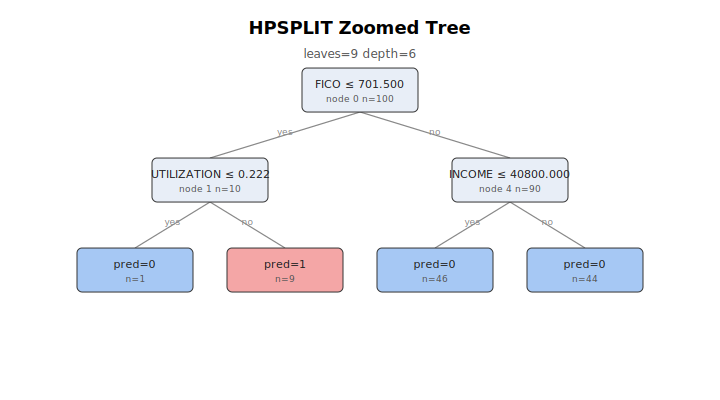

In [3]:
処理 hpsplit データ=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   分類 default home purpose;
   模型 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   出力 out=scored;
   見出 default     = 'デフォルト（債務不履行）'
         dti          = '負債収入比率'
         utilization  = '与信枠使用率'
         fico         = 'FICOスコア'
         credit_age   = '信用履歴年数'
         n_delinq     = '延滞回数'
         loan_amount  = '融資額'
         income       = '年収'
         home         = '居住形態'
         purpose      = '借入目的';
実行;

処理 印刷 データ=scored(obs=10);
   変数 p_default1 _node_ _leaf_;
   見出 p_default1 = '予測デフォルト確率'
         _node_      = 'ノード'
         _leaf_      = 'リーフ';
実行;

`zoomedtree` プロットは木の上位2階層を拡大する——アナリストが与信引受の要点ルールに落とし込む、最も情報量の多い分岐である。`OUTPUT OUT=` データセットは各申込者の予測デフォルト確率（`P_DEFAULT1`）と、割り当てられたノードおよびリーフ（`_NODE_`、`_LEAF_`）を運ぶため、リスク・監査チームは個々の判断を木に沿って遡って追跡し、申込者をモデル化されたリスクでランク付けできる。

## 4. デプロイ可能なスコアリングコードの出力

解釈可能なモデルの価値は、それが実運用に出せることにある。`CODE FILE=` は、自己完結型のDATAステップ——予測デフォルト確率とクラスに帰着する `IF/THEN` 分岐の入れ子連鎖——を書き出し、モデルサーバーなしで新しい申込ファイルに対して木のスコアを再現する。

In [4]:
処理 hpsplit データ=applicants seed=20260531;
   分類 default home purpose;
   模型 default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
   見出 default     = 'デフォルト（債務不履行）'
         dti          = '負債収入比率'
         utilization  = '与信枠使用率'
         fico         = 'FICOスコア'
         credit_age   = '信用履歴年数'
         n_delinq     = '延滞回数'
         loan_amount  = '融資額'
         income       = '年収'
         home         = '居住形態'
         purpose      = '借入目的';
実行;


                                                 The HPSPLIT Procedure                                                  

  Response variable: デフォルト（債務不履行）
  Class variable: デフォルト（債務不履行）
  Class variable: 居住形態
  Class variable: 借入目的
  Predictor variable: 負債収入比率
  Predictor variable: 与信枠使用率
  Predictor variable: FICOスコア
  Predictor variable: 信用履歴年数
  Predictor variable: 延滞回数
  Predictor variable: 融資額
  Predictor variable: 年収
  Predictor variable: 居住形態
  Predictor variable: 借入目的

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.04000


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## 結果の解釈

枝刈りされたエントロピー木は、リスクチームにコンパクトで監査可能な信用スコアカードを提供する：

- **分岐がポリシーを表現する。** 支配的な分岐——リボルビング与信枠使用率とFICO、続いて借入目的とDTI——は、与信引受チームがそのままハードなカットオフルールへ引き上げられる閾値そのものである。木全体の図は、すべての分岐条件とリーフを1枚の図に配置する。
- **コストコンプレキシティ枝刈り**は木がノイズを記憶するのを防ぐ。適合統計量（正解率、誤分類率、対数損失）は、2つのクラスをどれだけ明瞭に切り分けているかを要約する。
- **変数重要度とROC/AUC**は、どの属性がスコアカードに組み込まれるに値するかを正当化し、モデルリスクガバナンスのためにその判別力を文書化する。
- **`CODE FILE=` により運用可能になる**——出力されたDATAステップは新しい申込者をこの実行と同一にスコア付けするため、構築されたモデルがそのまま本番稼働するモデルとなる。

小規模な申込台帳では木は訓練データに厳密に適合する。実運用では、ポートフォリオ全体で木を成長させ、検証パーティションを保留し、確率カットオフを単純な0.5ではなく銀行の期待損失経済性（見逃した債務不履行のコストと、優良顧客を謝絶するコストのトレードオフ）に合わせて較正し、ポートフォリオの構成が変化するにつれて木を更新すべきである。